<a href="https://colab.research.google.com/github/jacobwechuli/mypython/blob/main/Image_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

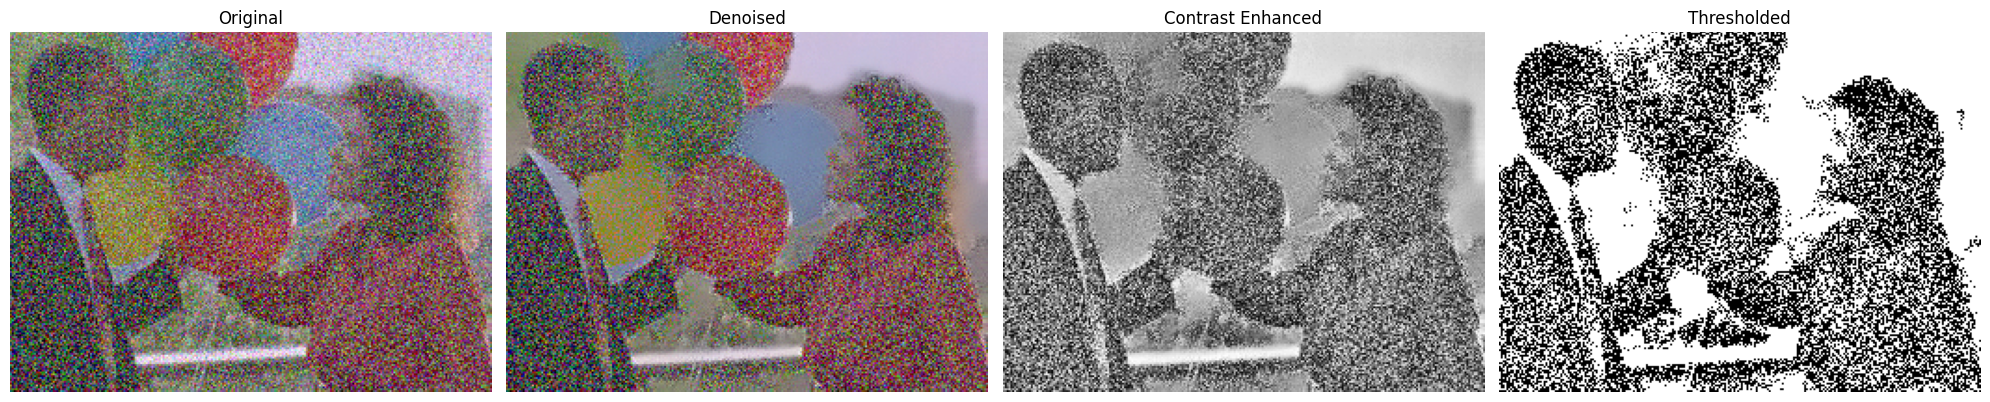

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================
# Install/import required libraries
# ============================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Load the image
# ============================================
# Upload via the folder icon on the left sidebar first,
# or run this to upload directly:
# from google.colab import files
# uploaded = files.upload()

image_path = 'noisy_image_sample.jpg'   # replace with your actual filename
original = cv2.imread(image_path)

# OpenCV loads images in BGR — convert to RGB for correct display with matplotlib
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

# ============================================
# Step 1: Denoising
# ============================================
# fastNlMeansDenoisingColored works well for color photos with grain/noise
denoised = cv2.fastNlMeansDenoisingColored(
    original,
    None,
    h=10,          # filter strength for luminance component (higher = more smoothing)
    hColor=10,      # filter strength for color components
    templateWindowSize=7,
    searchWindowSize=21
)

# ============================================
# Step 2: Contrast Enhancement
# ============================================
# Convert to grayscale first — thresholding and CLAHE work on single-channel images
gray = cv2.cvtColor(denoised, cv2.COLOR_BGR2GRAY)

# CLAHE (Contrast Limited Adaptive Histogram Equalization) improves local contrast
# without over-amplifying noise, unlike plain histogram equalization
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
contrast_enhanced = clahe.apply(gray)

# ============================================
# Step 3: Thresholding
# ============================================
# Otsu's method automatically picks the optimal threshold value —
# good default when you don't know the right cutoff in advance
_, thresholded = cv2.threshold(
    contrast_enhanced,
    0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Alternative: adaptive thresholding, useful if lighting is uneven across the image
# thresholded = cv2.adaptiveThreshold(
#     contrast_enhanced, 255,
#     cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
#     cv2.THRESH_BINARY,
#     11, 2
# )

# ============================================
# Display original vs. processed images side by side
# ============================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(original_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB))
axes[1].set_title('Denoised')
axes[1].axis('off')

axes[2].imshow(contrast_enhanced, cmap='gray')
axes[2].set_title('Contrast Enhanced')
axes[2].axis('off')

axes[3].imshow(thresholded, cmap='gray')
axes[3].set_title('Thresholded')
axes[3].axis('off')

plt.tight_layout()
plt.show()

# ============================================
# Save the processed image
# ============================================
cv2.imwrite('cleaned_image.jpg', thresholded)

# Download it from Colab
from google.colab import files
files.download('cleaned_image.jpg')